# Miniproyecto: Análisis Exploratorio de Hábitos de Salud (FitBit)
## Samsung Innovation Campus - Big Data 2026

Integrantes: Juan Velasquez

# 1. Contexto

El dataset utilizado corresponde al registro público de seguimiento de actividad física de FitBit (FitBit Fitness Tracker Data), compuesto por 33 usuarios monitoreados en un rango de 31 días. El propósito del análisis es explorar patrones reales de gasto calórico, sedentarismo, descanso nocturno y franjas de actividad horaria con el fin de generar recomendaciones de producto y retención aplicables a marcas de tecnología orientada a la salud.

# 2. Las 5 preguntas Guía

1. ¿Cómo se distribuyen los minutos del día entre sedentarismo y las distintas intensidades de actividad física?

2. ¿Qué proporción de las noches registradas cumple con el estándar médico de descanso diario (7 a 9 horas)?

3. ¿Existe una relación directa y lineal entre la cantidad de pasos diarios y el volumen de calorías quemadas?

4. ¿En qué franjas horarias exactas se concentran los picos de intensidad física de los usuarios a lo largo del día?

5. ¿Cómo varía el volumen de pasos promedio por hora y coincide con los momentos de mayor intensidad?

# 3. Desarrollo y Visualizaciones

# Instalación/Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


# Carga de datos

In [2]:
# Cargar los datasets seleccionados
df_activity = pd.read_csv('../data/raw/dailyActivity_merged.csv')
df_sleep = pd.read_csv('../data/raw/sleepDay_merged.csv')
df_intensities = pd.read_csv('../data/raw/hourlyIntensities_merged.csv')
df_hourly_steps = pd.read_csv('../data/raw/hourlySteps_merged.csv')

print(f"Daily Activity filas: {df_activity.shape[0]}")
print(f"Sleep Day filas: {df_sleep.shape[0]}")
print(f"Hourly Intensities filas: {df_intensities.shape[0]}")
print(f"Hourly Steps filas: {df_hourly_steps.shape[0]}")

Daily Activity filas: 940
Sleep Day filas: 413
Hourly Intensities filas: 22099
Hourly Steps filas: 22099


# Limpieza y formateo de fechas

In [10]:
# Estandarizar columnas de fecha
df_activity['ActivityDate'] = pd.to_datetime(df_activity['ActivityDate'], format='%m/%d/%Y')
df_sleep['SleepDay'] = pd.to_datetime(df_sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
df_sleep['SleepDate'] = df_sleep['SleepDay'].dt.date
df_activity['CleanDate'] = df_activity['ActivityDate'].dt.date

# Eliminar duplicados considerando Id y Fecha
df_activity = df_activity.drop_duplicates(subset=['Id', 'CleanDate'])
df_sleep = df_sleep.drop_duplicates(subset=['Id', 'SleepDate'])

# Unir actividad y sueño en una sola tabla consolidada
df_daily_merged = pd.merge(
    df_activity, 
    df_sleep, 
    left_on=['Id', 'CleanDate'], 
    right_on=['Id', 'SleepDate'], 
    how='inner'
)

print(f"Filas únicas de Actividad: {df_activity.shape[0]}")
print(f"Filas únicas de Sueño: {df_sleep.shape[0]}")
print(f"Filas unificadas (Actividad + Sueño): {df_daily_merged.shape[0]}")

Filas únicas de Actividad: 940
Filas únicas de Sueño: 410
Filas unificadas (Actividad + Sueño): 410


# Gráfico 1 - Distribución del tiempo diario (Pregunta 1)

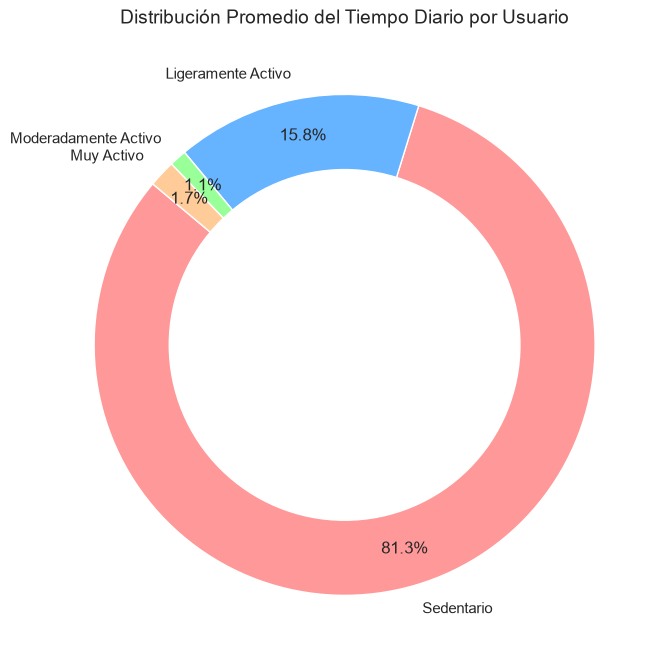

In [11]:
# Gráfico de dona: Minutos activos vs sedentarios
avg_sedentary = df_activity['SedentaryMinutes'].mean()
avg_light = df_activity['LightlyActiveMinutes'].mean()
avg_fair = df_activity['FairlyActiveMinutes'].mean()
avg_very = df_activity['VeryActiveMinutes'].mean()

labels = ['Sedentario', 'Ligeramente Activo', 'Moderadamente Activo', 'Muy Activo']
minutes = [avg_sedentary, avg_light, avg_fair, avg_very]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.figure(figsize=(7, 7))
plt.pie(minutes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Distribución Promedio del Tiempo Diario por Usuario', fontsize=14)
plt.tight_layout()
plt.show()

El sedentarismo domina de forma crítica la jornada de los usuarios, representando el 81.3% del tiempo registrado despiertos, frente a un escaso 1.7% en actividad intensa (Very Active) y 1.1% en actividad moderada. 

Esto evidencia que, aun usando un reloj inteligente de salud, el usuario promedio mantiene un estilo de vida predominantemente inactivo en su rutina diaria.

# Gráfico 2 - Cumplimiento de horas de sueño (Pregunta 2)

C:\Users\JUANP\AppData\Local\Temp\ipykernel_760\3823505223.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sleep, x='SleepCategory', order=order, palette='crest')


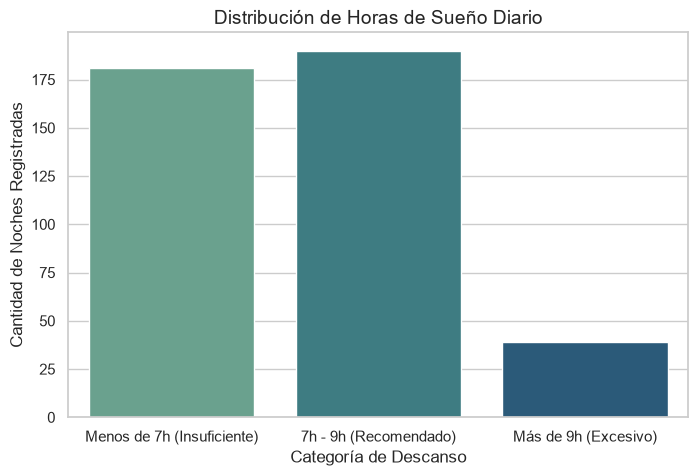

In [5]:
# Gráfico de barras: Categorías de descanso
def categorize_sleep(minutes):
    if minutes < 420:
        return 'Menos de 7h (Insuficiente)'
    elif 420 <= minutes <= 540:
        return '7h - 9h (Recomendado)'
    else:
        return 'Más de 9h (Excesivo)'

df_sleep['SleepCategory'] = df_sleep['TotalMinutesAsleep'].apply(categorize_sleep)

plt.figure(figsize=(8, 5))
order = ['Menos de 7h (Insuficiente)', '7h - 9h (Recomendado)', 'Más de 9h (Excesivo)']
sns.countplot(data=df_sleep, x='SleepCategory', order=order, palette='crest')
plt.title('Distribución de Horas de Sueño Diario', fontsize=14)
plt.xlabel('Categoría de Descanso')
plt.ylabel('Cantidad de Noches Registradas')
plt.show()

Existe un déficit de descanso considerable: prácticamente la mitad de las noches registradas (180 noches) cae por debajo de las 7 horas mínimas recomendadas (Insuficiente), situándose casi a la par con el grupo que cumple la meta óptima de 7 a 9 horas (190 noches). 

Menos del 10% supera las 9 horas de sueño.

# Gráfico 3 - Calorías según nivel de pasos (Pregunta 3)

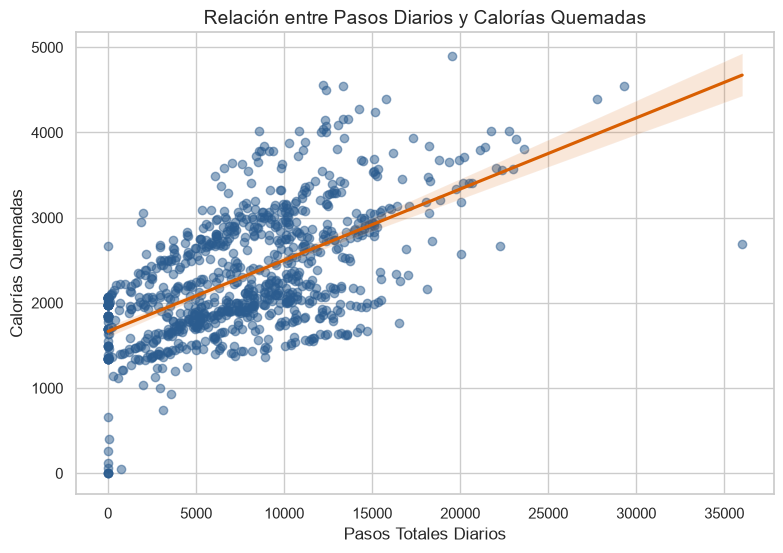

In [6]:
# Gráfico de dispersión/regresión: Pasos vs Calorías
plt.figure(figsize=(9, 6))
sns.regplot(data=df_activity, x='TotalSteps', y='Calories', 
            scatter_kws={'alpha':0.5, 'color':'#2b5c8f'}, line_kws={'color':'#d95f02'})
plt.title('Relación entre Pasos Diarios y Calorías Quemadas', fontsize=14)
plt.xlabel('Pasos Totales Diarios')
plt.ylabel('Calorías Quemadas')
plt.show()

La correlación es marcadamente positiva y lineal: a mayor cantidad de pasos, mayor es el gasto calórico diario. Aquellos registros por encima de los 10.000 pasos superan con consistencia las 2.500–3.000 calorías quemadas, confirmando que la caminata continua es el motor principal del gasto calórico del usuario.

# Gráfico 4 - Picos de intensidad por hora (Pregunta 4)

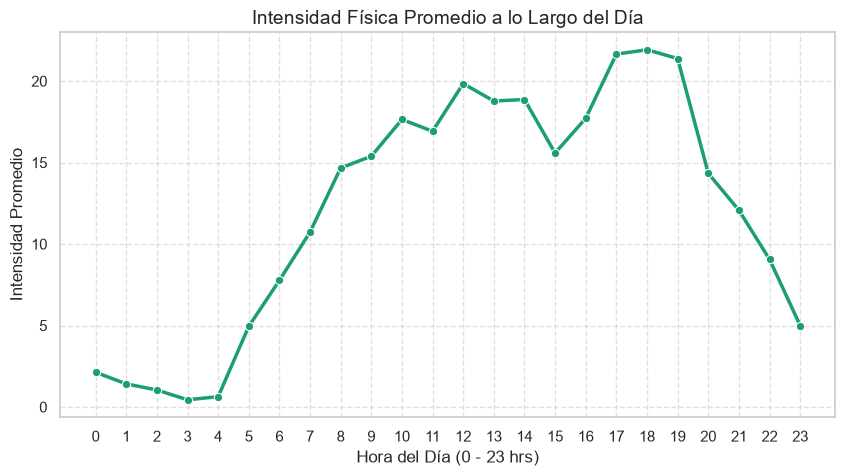

In [7]:
# Parsear fechas de intensidades horarias
df_intensities['ActivityHour_dt'] = pd.to_datetime(df_intensities['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')
df_intensities['Hour'] = df_intensities['ActivityHour_dt'].dt.hour

hourly_summary = df_intensities.groupby('Hour')['TotalIntensity'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_summary, x='Hour', y='TotalIntensity', marker='o', color='#1b9e77', linewidth=2.5)
plt.title('Intensidad Física Promedio a lo Largo del Día', fontsize=14)
plt.xlabel('Hora del Día (0 - 23 hrs)')
plt.ylabel('Intensidad Promedio')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La intensidad física no es constante: presenta dos picos pronunciados muy definidos. El primero ocurre a las 12:00–14:00 hrs (almuerzo) alcanzando 20 puntos de intensidad, y el pico principal se produce entre las 17:00 y 19:00 hrs (salida laboral/gimnasio) superando los 22 puntos de intensidad.

# Gráfico 5 - Paso por hora promedio (Pregunta 5)

C:\Users\JUANP\AppData\Local\Temp\ipykernel_760\3658563977.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_steps_summary, x='Hour', y='StepTotal', palette='Blues_d')


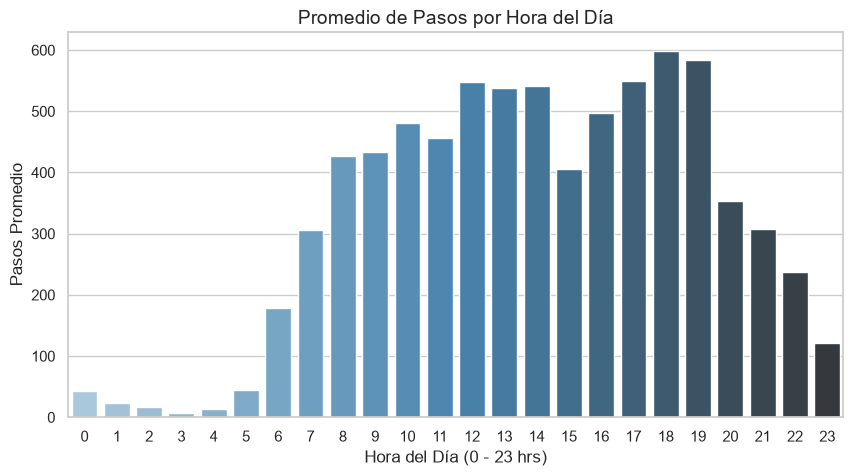

In [8]:
# Parsear fecha y hora para pasos horarios
df_hourly_steps['ActivityHour_dt'] = pd.to_datetime(df_hourly_steps['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')
df_hourly_steps['Hour'] = df_hourly_steps['ActivityHour_dt'].dt.hour

hourly_steps_summary = df_hourly_steps.groupby('Hour')['StepTotal'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_steps_summary, x='Hour', y='StepTotal', palette='Blues_d')
plt.title('Promedio de Pasos por Hora del Día', fontsize=14)
plt.xlabel('Hora del Día (0 - 23 hrs)')
plt.ylabel('Pasos Promedio')
plt.show()

El volumen de pasos refleja fielmente la curva de intensidad: el récord de pasos se alcanza a las 18:00 hrs (promediando cerca de 600 pasos en esa sola hora). La franja de las 15:00 hrs muestra un valle de inactividad notable (400 pasos) antes del repunte de la tarde-noche.

# 5. Recomendaciones Estratégicas

1. Notificaciones Push contra el valle de sedentarismo (14:30–15:30 hrs):
Dado que los datos demuestran una caída abrupta de actividad a las 15:00 hrs sumada a un 81.3% de sedentarismo global, la aplicación debería emitir recordatorios discretos de "romper el sedentarismo" (caminatas cortas de 250 pasos) entre las 14:30 y las 15:00 hrs para activar al usuario antes del final de su jornada laboral.  

2. Alertas predictivas de preparación para el sueño:
Dado el alto volumen de noches con menos de 7 horas de descanso, el sistema debe alertar al usuario 45 minutos antes de su hora habitual de acostarse recomendando reducir el brillo de pantallas y sugiriendo técnicas de respiración/relajación.  

3. Campañas y retos comunitarios fijados a las 18:00 hrs:
Aprovechando que las 18:00 hrs es el momento natural donde los usuarios ya están más predispuestos al movimiento (600 pasos/hora y pico de intensidad máxima), la app debe lanzar retos grupales en vivo o entrenamientos guiados en esa franja horaria para maximizar el engagement.

# 6. Limitaciones

* Sesgo muestral: La muestra contempla únicamente 33 usuarios en un periodo de 31 días, sin variables sociodemográficas (género, edad, profesión) para segmentar con mayor granularidad.  

* Disparidad de adherencia: De los 940 registros diarios de actividad, solo 410 contaban con mediciones completas de sueño, lo que denota que los usuarios suelen quitarse el dispositivo para dormir o cargarlo durante la noche.